# Comparaison des trois variantes de γ

**Modèle de Chiarella étendu** — Majewski, Ciliberti, Bouchaud (2020)

Ce notebook compare les trois variantes du paramètre de saturation γ sur 1 000 mois (≈ 83 ans) de simulation :

| Variante | Formulation | Paramètre |
|----------|-------------|-----------|
| **Baseline** | $\gamma(t) = \gamma_0$ | — |
| **Adaptatif linéaire** | $\gamma(t) = \gamma_0 \cdot \left(1 + \theta \cdot \dfrac{\sigma_{\text{réal}}(t)}{\sigma_{\text{baseline}}}\right)$ | $\theta = 1.0$ |
| **Mispricing** | $\gamma(t) = \gamma_0 \cdot \exp\!\left(\lambda \cdot \lvert P_t - V_t \rvert\right)$ | $\lambda = 1.0$ |

**Hypothèses testées** :
- L'adaptatif linéaire (proxy VIX) réduit-il les bulles extrêmes ?
- Le mispricing (écart prix/fondamentale) crée-t-il un mécanisme de stabilisation endogène ?

In [1]:
import sys
from pathlib import Path

# Assure que les modules src/ sont accessibles depuis notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from src.simulation import run_baseline, run_adaptive, run_mispricing, merge_results, VOL_WINDOW_MONTHS
from src.analysis import (
    compute_returns,
    rolling_volatility,
    return_statistics,
    compare_models,
    gamma_statistics,
)

# Style global
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

# Palette cohérente pour les 3 modèles
COLORS = {"baseline": "steelblue", "adaptive": "darkorange", "mispricing": "#8B2FC9"}

SEED = 2024
print("Imports OK")

Imports OK


In [2]:
# ── Simulations ──────────────────────────────────────────────────────────────
print("Simulation baseline …")
res_base, df_base = run_baseline(seed=SEED)

print("Simulation adaptative (θ=1.0) …")
res_adap, df_adap = run_adaptive(theta=1.0, seed=SEED)

print("Simulation mispricing (λ=1.0) …")
res_misp, df_misp = run_mispricing(lambda_=1.0, seed=SEED)

# Fusion des trois DataFrames
df = merge_results(df_base, df_adap)
df = pd.merge(df, df_misp, on="t", how="inner")

# Rendements et mispricing
df["baseline_ret"]        = df["baseline_P"].diff()
df["adaptive_ret"]        = df["adaptive_P"].diff()
df["mispricing_ret"]      = df["mispricing_P"].diff()
df["baseline_mispricing"] = df["baseline_P"] - df["baseline_V"]
df["adaptive_mispricing"] = df["adaptive_P"] - df["adaptive_V"]
df["mispricing_mispricing"] = df["mispricing_P"] - df["mispricing_V"]

# Volatilité réalisée glissante (12 mois) par modèle
for label in ("baseline", "adaptive", "mispricing"):
    r = df[f"{label}_ret"].dropna().to_numpy()
    df.loc[df.index[1:], f"{label}_vol"] = rolling_volatility(r, window=VOL_WINDOW_MONTHS)

print(f"\nDataFrame : {df.shape[0]} pas × {df.shape[1]} colonnes")
print(f"γ adaptatif  — mean={res_adap.gamma.mean():.3f}  min={res_adap.gamma.min():.3f}  max={res_adap.gamma.max():.3f}")
print(f"γ mispricing — mean={res_misp.gamma.mean():.3f}  min={res_misp.gamma.min():.3f}  max={res_misp.gamma.max():.3f}")

Simulation baseline …
Simulation adaptative (θ=1.0) …
Simulation mispricing (λ=1.0) …

DataFrame : 1001 pas × 22 colonnes
γ adaptatif  — mean=3.852  min=2.000  max=4.943
γ mispricing — mean=2.248  min=2.000  max=3.217


---
## Figure 1 — Trajectoires de prix et valeur fondamentale

/var/folders/w7/0j__nhp56rzds_x7q38c8rsr0000gn/T/ipykernel_8101/2892918461.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


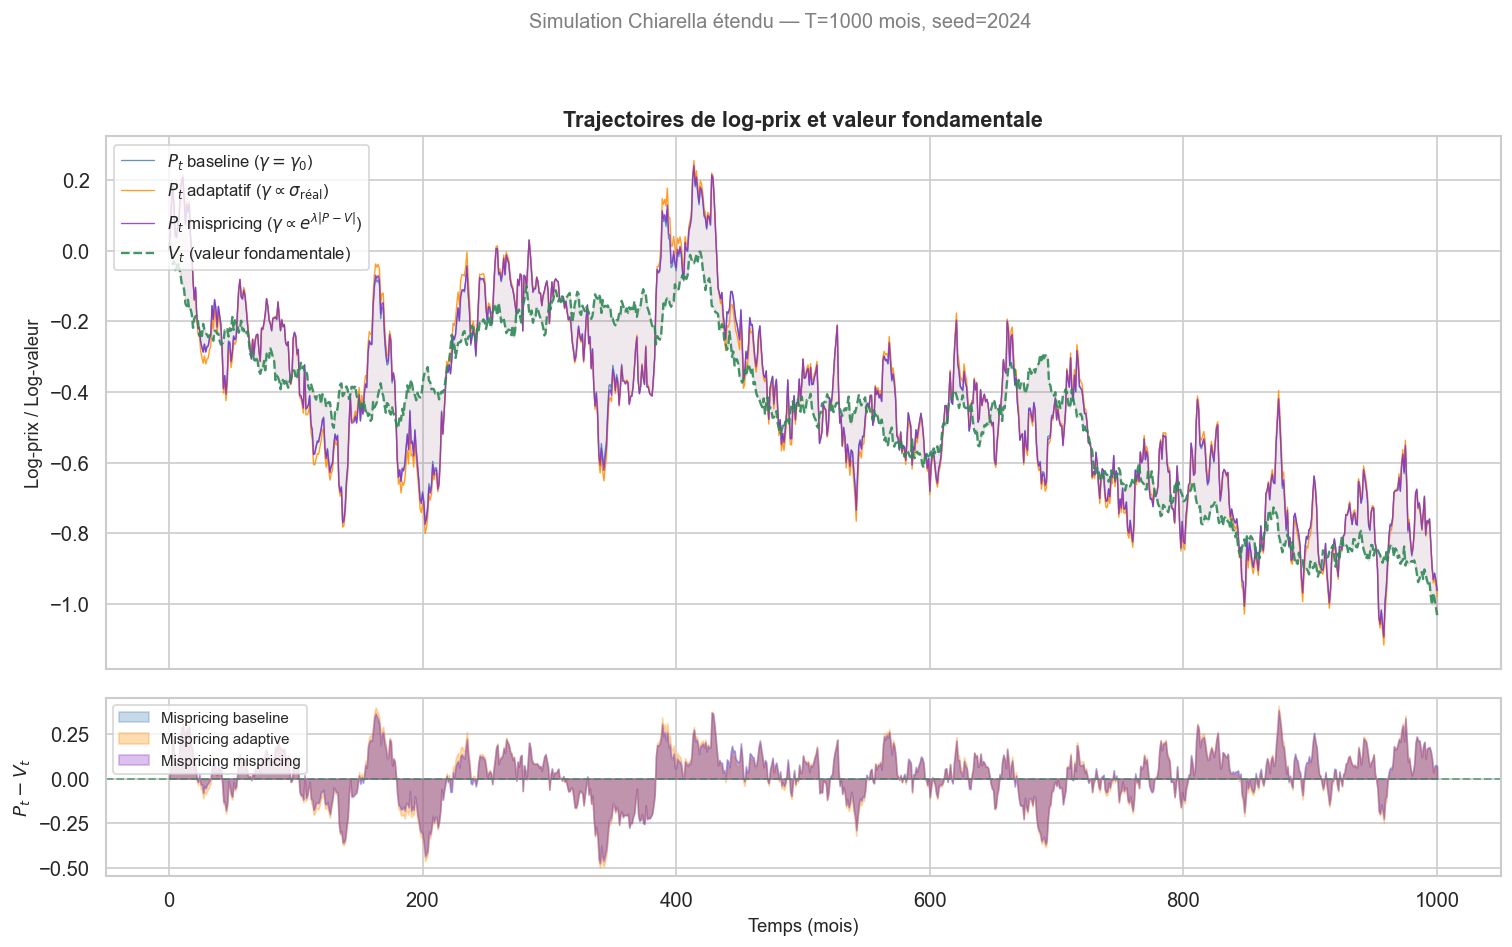

In [3]:
t = df["t"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

# ── Panneau supérieur : trajectoires ─────────────────────────────────────────
ax = axes[0]
ax.plot(t, df["baseline_P"], lw=0.8, alpha=0.85, color=COLORS["baseline"],
        label=r"$P_t$ baseline ($\gamma=\gamma_0$)")
ax.plot(t, df["adaptive_P"], lw=0.8, alpha=0.85, color=COLORS["adaptive"],
        label=r"$P_t$ adaptatif ($\gamma \propto \sigma_{\text{réal}}$)")
ax.plot(t, df["mispricing_P"], lw=0.8, alpha=0.85, color=COLORS["mispricing"],
        label=r"$P_t$ mispricing ($\gamma \propto e^{\lambda|P-V|}$)")
ax.plot(t, df["baseline_V"], lw=1.4, ls="--", color="seagreen", alpha=0.9,
        label=r"$V_t$ (valeur fondamentale)")

for label in ("baseline", "adaptive", "mispricing"):
    ax.fill_between(t, df[f"{label}_P"], df["baseline_V"],
                    alpha=0.05, color=COLORS[label])

ax.set_ylabel("Log-prix / Log-valeur")
ax.set_title("Trajectoires de log-prix et valeur fondamentale", fontweight="bold")
ax.legend(loc="upper left")

# ── Panneau inférieur : mispricing ────────────────────────────────────────────
ax2 = axes[1]
ax2.axhline(0, color="seagreen", lw=1.2, ls="--", alpha=0.6)
for label in ("baseline", "adaptive", "mispricing"):
    ax2.fill_between(t, df[f"{label}_mispricing"], 0,
                     alpha=0.3, color=COLORS[label], label=f"Mispricing {label}")

ax2.set_xlabel("Temps (mois)")
ax2.set_ylabel(r"$P_t - V_t$")
ax2.legend(loc="upper left", fontsize=9)

plt.suptitle(
    f"Simulation Chiarella étendu — T={int(t[-1])} mois, seed={SEED}",
    y=1.01, fontsize=12, color="gray"
)
plt.tight_layout()
plt.savefig("fig1_trajectoires.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Figure 2 — Évolution de γ(t) pour les deux modèles dynamiques

- **Adaptatif** : $\gamma(t) = \gamma_0 \cdot (1 + \theta \cdot \sigma_{\text{réal}}(t)/\sigma_{\text{baseline}})$ — réagit à la volatilité réalisée (proxy VIX externe)
- **Mispricing** : $\gamma(t) = \gamma_0 \cdot \exp(\lambda \cdot |P_t - V_t|)$ — réagit à l'écart prix/fondamentale (mécanisme endogène)

/var/folders/w7/0j__nhp56rzds_x7q38c8rsr0000gn/T/ipykernel_8101/102826291.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


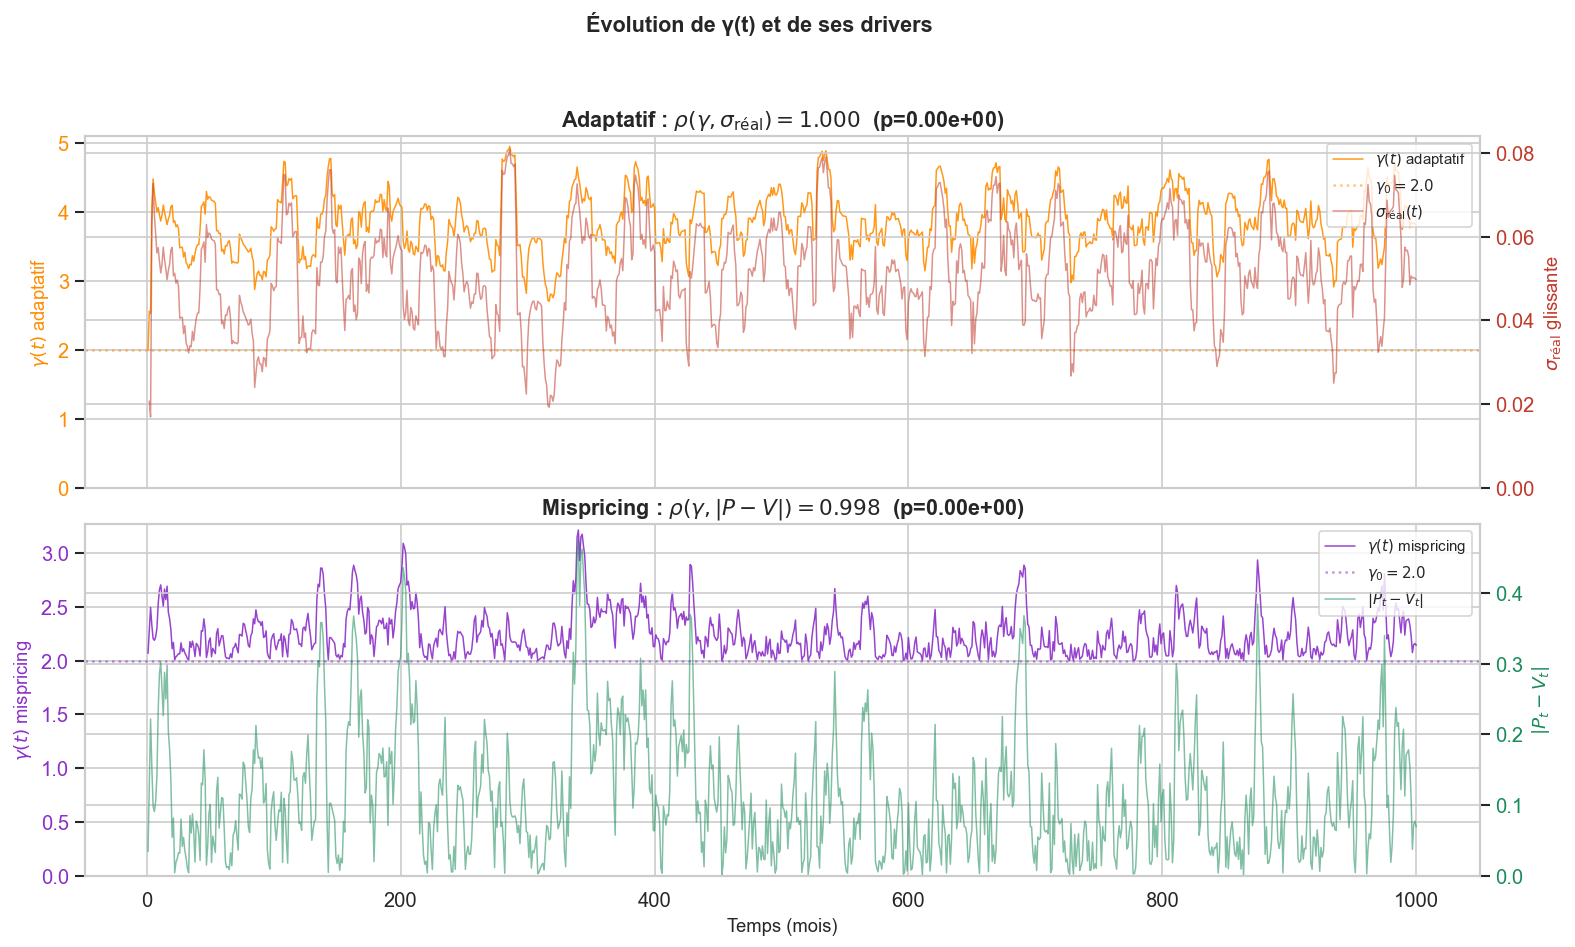

Corr. adaptatif  γ ↔ σ_réal : ρ = 0.9996  (p = 0.00e+00)
Corr. mispricing γ ↔ |P-V|  : ρ = 0.9979  (p = 0.00e+00)


In [4]:
t_ret = t[1:]   # grille temporelle alignée sur les rendements

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                          gridspec_kw={"hspace": 0.1})

# ── (A) γ adaptatif vs σ_réalisée ────────────────────────────────────────────
ax1 = axes[0]
gamma_adap = df["adaptive_gamma"].to_numpy()[1:]
vol_adap   = df["adaptive_vol"].to_numpy()[1:]

color_g = COLORS["adaptive"]
color_v = "#C0392B"

ax1.plot(t_ret, gamma_adap, lw=0.9, alpha=0.9, color=color_g,
         label=r"$\gamma(t)$ adaptatif")
ax1.axhline(2.0, color=color_g, ls=":", lw=1.5, alpha=0.5,
            label=r"$\gamma_0 = 2.0$")
ax1.set_ylabel(r"$\gamma(t)$ adaptatif", color=color_g)
ax1.tick_params(axis="y", labelcolor=color_g)
ax1.set_ylim(bottom=0)

ax1b = ax1.twinx()
ax1b.plot(t_ret, vol_adap, lw=0.9, alpha=0.55, color=color_v,
          label=r"$\sigma_{\text{réal}}(t)$")
ax1b.set_ylabel(r"$\sigma_{\text{réal}}$ glissante", color=color_v)
ax1b.tick_params(axis="y", labelcolor=color_v)
ax1b.set_ylim(bottom=0)

mask_a = ~np.isnan(vol_adap)
rho_a, pval_a = stats.pearsonr(gamma_adap[mask_a], vol_adap[mask_a])

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc="upper right", fontsize=9)
ax1.set_title(
    rf"Adaptatif : $\rho(\gamma, \sigma_{{\text{{réal}}}}) = {rho_a:.3f}$  (p={pval_a:.2e})",
    fontweight="bold"
)

# ── (B) γ mispricing vs |P - V| ──────────────────────────────────────────────
ax2 = axes[1]
gamma_misp   = df["mispricing_gamma"].to_numpy()[1:]
abs_mispricing = np.abs(df["mispricing_mispricing"].to_numpy()[1:])

color_m = COLORS["mispricing"]
color_mp = "#1A8C5A"

ax2.plot(t_ret, gamma_misp, lw=0.9, alpha=0.9, color=color_m,
         label=r"$\gamma(t)$ mispricing")
ax2.axhline(2.0, color=color_m, ls=":", lw=1.5, alpha=0.5,
            label=r"$\gamma_0 = 2.0$")
ax2.set_ylabel(r"$\gamma(t)$ mispricing", color=color_m)
ax2.tick_params(axis="y", labelcolor=color_m)
ax2.set_ylim(bottom=0)
ax2.set_xlabel("Temps (mois)")

ax2b = ax2.twinx()
ax2b.plot(t_ret, abs_mispricing, lw=0.9, alpha=0.55, color=color_mp,
          label=r"$|P_t - V_t|$")
ax2b.set_ylabel(r"$|P_t - V_t|$", color=color_mp)
ax2b.tick_params(axis="y", labelcolor=color_mp)
ax2b.set_ylim(bottom=0)

rho_m, pval_m = stats.pearsonr(gamma_misp, abs_mispricing)

lines3, labs3 = ax2.get_legend_handles_labels()
lines4, labs4 = ax2b.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labs3 + labs4, loc="upper right", fontsize=9)
ax2.set_title(
    rf"Mispricing : $\rho(\gamma, |P-V|) = {rho_m:.3f}$  (p={pval_m:.2e})",
    fontweight="bold"
)

plt.suptitle("Évolution de γ(t) et de ses drivers", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig2_gamma_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Corr. adaptatif  γ ↔ σ_réal : ρ = {rho_a:.4f}  (p = {pval_a:.2e})")
print(f"Corr. mispricing γ ↔ |P-V|  : ρ = {rho_m:.4f}  (p = {pval_m:.2e})")

---
## Figure 3 — Distribution du mispricing $P_t - V_t$ (3 modèles)

On compare les queues de distribution pour tester si les γ dynamiques réduisent les bulles extrêmes.
Le modèle mispricing crée un **mécanisme de rétroaction endogène** : plus la bulle est grande, plus γ augmente, freinant les trend-followers.

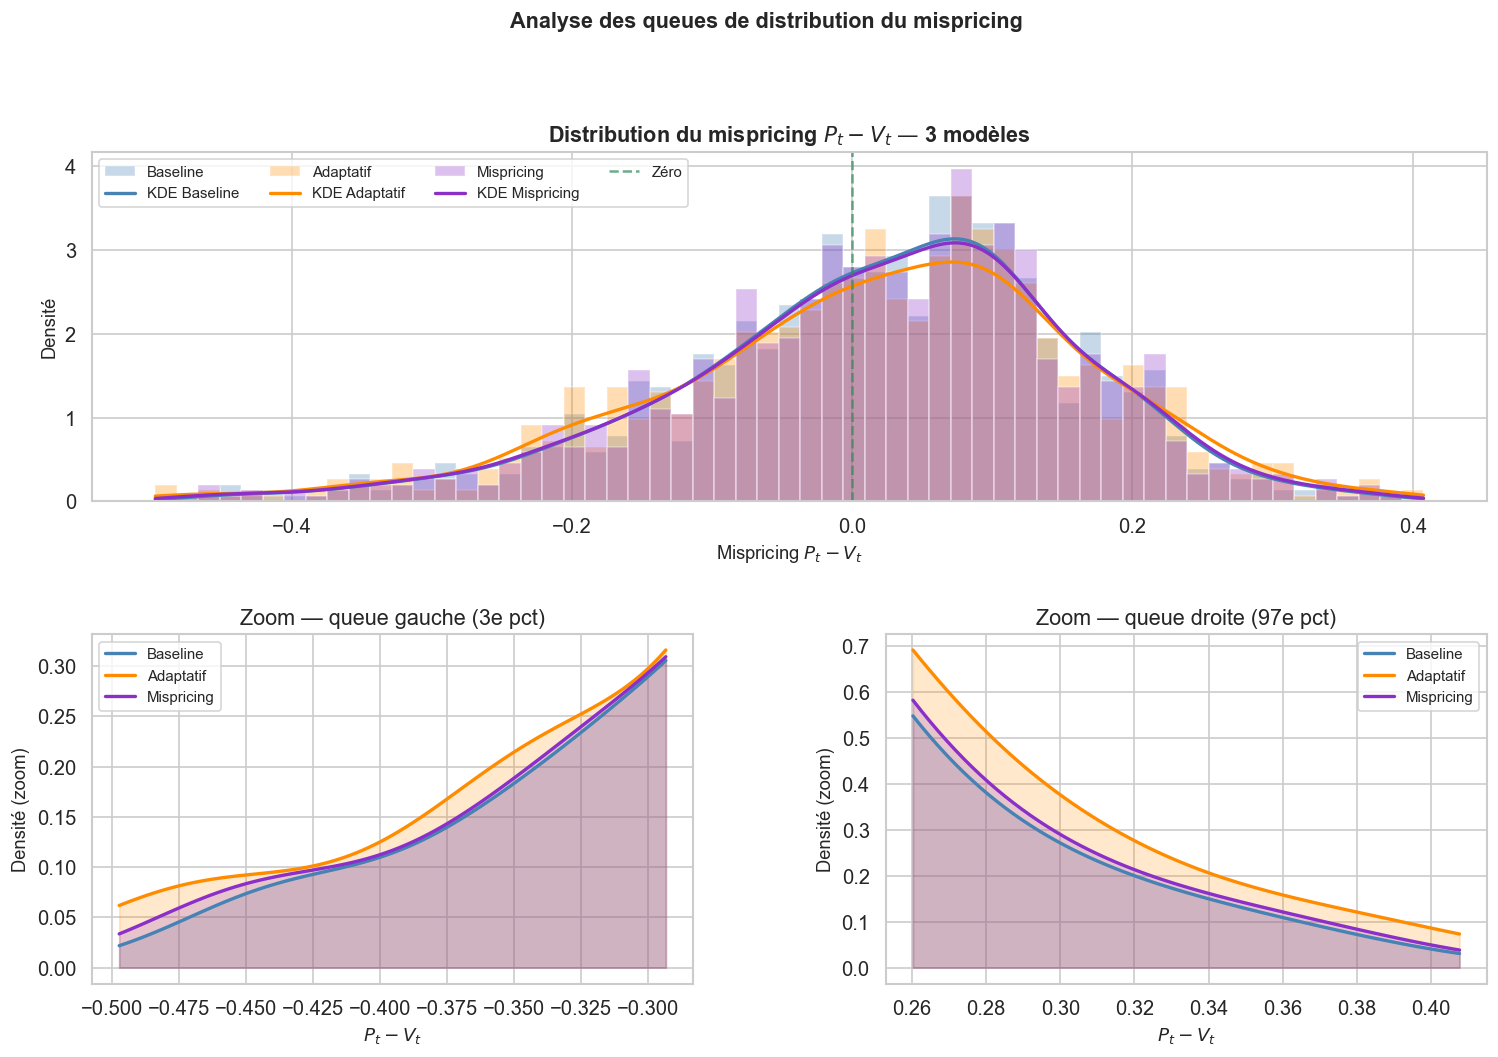

In [5]:
mp_base = df["baseline_mispricing"].dropna().to_numpy()
mp_adap = df["adaptive_mispricing"].dropna().to_numpy()
mp_misp = df["mispricing_mispricing"].dropna().to_numpy()

all_mp = np.concatenate([mp_base, mp_adap, mp_misp])
bins   = np.linspace(all_mp.min(), all_mp.max(), 60)
x_grid = np.linspace(bins[0], bins[-1], 400)

kde_base = stats.gaussian_kde(mp_base)
kde_adap = stats.gaussian_kde(mp_adap)
kde_misp = stats.gaussian_kde(mp_misp)
kdes = {"baseline": kde_base, "adaptive": kde_adap, "mispricing": kde_misp}
mps  = {"baseline": mp_base,  "adaptive": mp_adap,  "mispricing": mp_misp}
labels_fr = {"baseline": "Baseline", "adaptive": "Adaptatif", "mispricing": "Mispricing"}

fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── (A) Histogrammes superposés + KDE ────────────────────────────────────────
ax_hist = fig.add_subplot(gs[0, :])
for label, mp in mps.items():
    ax_hist.hist(mp, bins=bins, density=True, alpha=0.30,
                 color=COLORS[label], label=labels_fr[label])
    ax_hist.plot(x_grid, kdes[label](x_grid), lw=2, color=COLORS[label],
                 label=f"KDE {labels_fr[label]}")

ax_hist.axvline(0, color="seagreen", ls="--", lw=1.5, alpha=0.7, label="Zéro")
ax_hist.set_xlabel(r"Mispricing $P_t - V_t$")
ax_hist.set_ylabel("Densité")
ax_hist.set_title(r"Distribution du mispricing $P_t - V_t$ — 3 modèles", fontweight="bold")
ax_hist.legend(ncol=4, fontsize=9)

# ── (B) Queue gauche ─────────────────────────────────────────────────────────
ax_left = fig.add_subplot(gs[1, 0])
q3 = np.percentile(all_mp, 3)
mask_l = x_grid < q3
for label in ("baseline", "adaptive", "mispricing"):
    y = kdes[label](x_grid[mask_l])
    ax_left.plot(x_grid[mask_l], y, lw=2, color=COLORS[label], label=labels_fr[label])
    ax_left.fill_between(x_grid[mask_l], y, alpha=0.2, color=COLORS[label])
ax_left.set_xlabel(r"$P_t - V_t$")
ax_left.set_ylabel("Densité (zoom)")
ax_left.set_title("Zoom — queue gauche (3e pct)")
ax_left.legend(fontsize=9)

# ── (C) Queue droite ─────────────────────────────────────────────────────────
ax_right = fig.add_subplot(gs[1, 1])
q97 = np.percentile(all_mp, 97)
mask_r = x_grid > q97
for label in ("baseline", "adaptive", "mispricing"):
    y = kdes[label](x_grid[mask_r])
    ax_right.plot(x_grid[mask_r], y, lw=2, color=COLORS[label], label=labels_fr[label])
    ax_right.fill_between(x_grid[mask_r], y, alpha=0.2, color=COLORS[label])
ax_right.set_xlabel(r"$P_t - V_t$")
ax_right.set_ylabel("Densité (zoom)")
ax_right.set_title("Zoom — queue droite (97e pct)")
ax_right.legend(fontsize=9)

plt.suptitle("Analyse des queues de distribution du mispricing",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("fig3_mispricing_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Tableau récapitulatif des statistiques

In [6]:
# ── Statistiques des rendements (3 modèles) ───────────────────────────────────
ret_dict = {
    "baseline":   df["baseline_ret"].dropna().to_numpy(),
    "adaptive":   df["adaptive_ret"].dropna().to_numpy(),
    "mispricing": df["mispricing_ret"].dropna().to_numpy(),
}
report = compare_models(ret_dict, annualization_factor=np.sqrt(12))

# Statistiques de γ(t)
gamma_dict = {
    "baseline":   res_base.gamma,
    "adaptive":   res_adap.gamma,
    "mispricing": res_misp.gamma,
}
gamma_rows = {name: gamma_statistics(g) for name, g in gamma_dict.items()}
gamma_df = pd.DataFrame(gamma_rows).T
gamma_df.index.name = "model"

# Statistiques du mispricing
def _mp_stats(mp: np.ndarray) -> dict:
    return {
        "mp_mean":    mp.mean(),
        "mp_std":     mp.std(ddof=1),
        "mp_skew":    stats.skew(mp),
        "mp_kurt":    stats.kurtosis(mp, fisher=True),
        "mp_q1pct":   np.percentile(mp, 1),
        "mp_q99pct":  np.percentile(mp, 99),
        "mp_max_abs": np.abs(mp).max(),
    }

mp_stats = pd.DataFrame({
    "baseline":   _mp_stats(mp_base),
    "adaptive":   _mp_stats(mp_adap),
    "mispricing": _mp_stats(mp_misp),
}).T
mp_stats.index.name = "model"

full_stats = pd.concat([report, gamma_df, mp_stats], axis=1)
full_stats.index.name = "Modèle"

print("=== Statistiques complètes — 3 modèles ===")
display(full_stats.round(4))

# ── Réductions relatives par rapport au baseline ─────────────────────────────
print("\n── Variation par rapport au baseline (en %) ──")
for label in ("adaptive", "mispricing"):
    d_std = (mps[label].std(ddof=1) - mp_base.std(ddof=1)) / mp_base.std(ddof=1) * 100
    d_max = (np.abs(mps[label]).max() - np.abs(mp_base).max()) / np.abs(mp_base).max() * 100
    print(f"  {label:12s} → Δstd(mp) = {d_std:+.2f} %   Δmax|mp| = {d_max:+.2f} %")
print("(valeur négative = réduction des extrêmes par rapport au baseline)")

=== Statistiques complètes — 3 modèles ===


,mean,vol,skewness,kurt_excess,jarque_bera_pval,n_obs,gamma_mean,gamma_std,gamma_min,gamma_max,gamma_median,mp_mean,mp_std,mp_skew,mp_kurt,mp_q1pct,mp_q99pct,mp_max_abs
Modèle,,,,,,,,,,,,,,,,,,
baseline,-0.0033,0.1805,0.0435,0.0738,0.7625,1000,2.0000,0.0000,2.0,2.0000,2.0000,0.0191,0.1387,-0.5178,0.4710,-0.3614,0.3023,0.4656
adaptive,-0.0034,0.1808,0.0484,0.0662,0.7509,1000,3.8517,0.4252,2.0,4.9434,3.8449,0.0171,0.1500,-0.4654,0.4163,-0.3856,0.3393,0.4973
mispricing,-0.0033,0.1805,0.0446,0.0720,0.7608,1000,2.2477,0.2056,2.0,3.2171,2.1984,0.0192,0.1412,-0.5263,0.5094,-0.3684,0.3084,0.4753



── Variation par rapport au baseline (en %) ──
  adaptive     → Δstd(mp) = +8.12 %   Δmax|mp| = +6.81 %
  mispricing   → Δstd(mp) = +1.76 %   Δmax|mp| = +2.08 %
(valeur négative = réduction des extrêmes par rapport au baseline)
